# YuvaIntern Week 1 — Python for Machine Learning & Data Preprocessing

## Titanic Passenger Dataset

### Data Cleaning, Missing-Value Handling, Feature Selection, Encoding, Normalization & EDA

**Intern:** Sahil Sant  
**Internship:** AI Pioneers Internship (Machine Learning Internship)  
**Task:** Week 1 — Python for Machine Learning & Data Preprocessing

---

### Objective

The objective of this project is to demonstrate a complete introductory machine-learning data preprocessing workflow using Python, Pandas, NumPy, and Matplotlib.

The workflow includes:

- Loading and inspecting a real-world dataset
- Identifying missing values
- Selecting relevant features
- Handling missing data
- Encoding categorical variables
- Normalizing numerical features
- Performing exploratory data analysis
- Exporting a clean machine-learning-ready dataset


In [17]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [18]:
from pathlib import Path

BASE_DIR = Path.cwd()

DATA_DIR = BASE_DIR / "data"
FIGURES_DIR = BASE_DIR / "figures"

INPUT_FILE = DATA_DIR / "titanic.csv"

df = pd.read_csv(INPUT_FILE)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (891, 12)


## 1. Initial Data Inspection

The first step in a machine-learning workflow is understanding the structure and quality of the raw data.

I inspect the dataset dimensions, column names, data types, and first few records before making preprocessing decisions.

In [19]:
print("Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nFirst 5 Rows:")
display(df.head())

Shape:
(891, 12)

Columns:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

First 5 Rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. Missing Value Analysis

Missing values can cause errors during machine-learning model training and may affect the quality of analysis.

The raw Titanic dataset contains missing values in the `Age`, `Cabin`, and `Embarked` columns. These values are analyzed before deciding how they should be treated.

In [20]:
missing_values = df.isna().sum()

print("Missing values by column:")
display(missing_values)

Missing values by column:


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [21]:
missing_values[missing_values > 0]

Age         177
Cabin       687
Embarked      2
dtype: int64

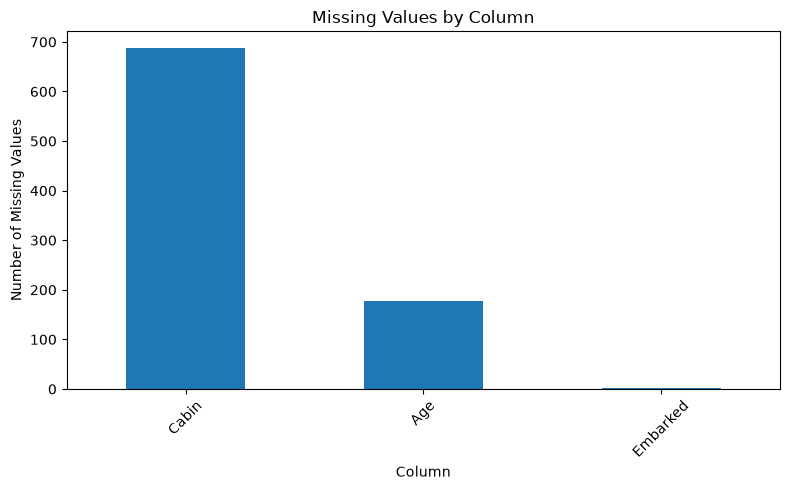

In [22]:
missing = missing_values[missing_values > 0]

plt.figure(figsize=(8, 5))

missing.sort_values(ascending=False).plot(kind="bar")

plt.title("Missing Values by Column")
plt.xlabel("Column")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 3. Feature Selection

Some columns are not suitable for this introductory machine-learning preprocessing pipeline.

- `PassengerId` is only an identifier.
- `Name` is high-cardinality text.
- `Ticket` is high-cardinality text.
- `Cabin` contains extensive missing data.

These columns are therefore removed from the selected feature set.

In [23]:
columns_to_drop = [
    "PassengerId",
    "Name",
    "Ticket",
    "Cabin"
]

df = df.drop(columns=columns_to_drop)

print("Columns after feature selection:")
print(df.columns.tolist())

Columns after feature selection:
['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


## 4. Handling Missing Values

### Age

The missing `Age` values are replaced using the median age. Median imputation is useful because it is less affected by extreme values than the mean.

### Embarked

Only two `Embarked` values are missing, so the most frequent category (mode) is used.

In [24]:
age_median = df["Age"].median()
embarked_mode = df["Embarked"].mode()[0]

print("Age median:", age_median)
print("Embarked mode:", embarked_mode)

df["Age"] = df["Age"].fillna(age_median)
df["Embarked"] = df["Embarked"].fillna(embarked_mode)

print("\nRemaining missing values:")
display(df.isna().sum())

Age median: 28.0
Embarked mode: S

Remaining missing values:


Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

## 5. Categorical Encoding

Machine-learning algorithms generally require numerical inputs.

The `Sex` column is binary encoded:

- male → 0
- female → 1

The `Embarked` column contains more than two categories, so one-hot encoding is used. This creates separate binary columns without imposing an artificial numerical ranking between categories.

In [25]:
df["Sex"] = df["Sex"].map({
    "male": 0,
    "female": 1
})

df = pd.get_dummies(
    df,
    columns=["Embarked"],
    dtype=int
)

print("Columns after encoding:")
print(df.columns.tolist())

Columns after encoding:
['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_C', 'Embarked_Q', 'Embarked_S']


## 6. Numerical Normalization

Min-Max normalization is applied to `Age`, `Fare`, `SibSp`, and `Parch`.

The transformation is:

x_scaled = (x - minimum) / (maximum - minimum)

This places the selected numerical features on a comparable 0–1 scale.

In [26]:
numeric_columns = [
    "Age",
    "Fare",
    "SibSp",
    "Parch"
]

for column in numeric_columns:
    minimum = df[column].min()
    maximum = df[column].max()

    if maximum != minimum:
        df[column] = (
            df[column] - minimum
        ) / (
            maximum - minimum
        )

print("Normalization completed.")

display(df[numeric_columns].head())

Normalization completed.


,Age,Fare,SibSp,Parch
0,0.271174,0.014151,0.125,0.0
1,0.472229,0.139136,0.125,0.0
2,0.321438,0.015469,0.000,0.0
3,0.434531,0.103644,0.125,0.0
4,0.434531,0.015713,0.000,0.0


## 7. Final Data Quality Check

After preprocessing, the dataset is checked again for missing values and its final dimensions are verified.

In [27]:
remaining_missing = df.isna().sum().sum()

print("Final shape:", df.shape)
print("Remaining missing values:", remaining_missing)

assert df.shape == (891, 10)
assert remaining_missing == 0

print("\n✓ Data quality checks passed.")

Final shape: (891, 10)
Remaining missing values: 0

✓ Data quality checks passed.


## 8. Exploratory Data Analysis

Exploratory Data Analysis (EDA) helps understand patterns and relationships in the processed dataset before machine-learning modeling.

The following visualizations are examined:

1. Survival distribution
2. Age distribution
3. Survival rate by passenger class
4. Correlation between numerical features

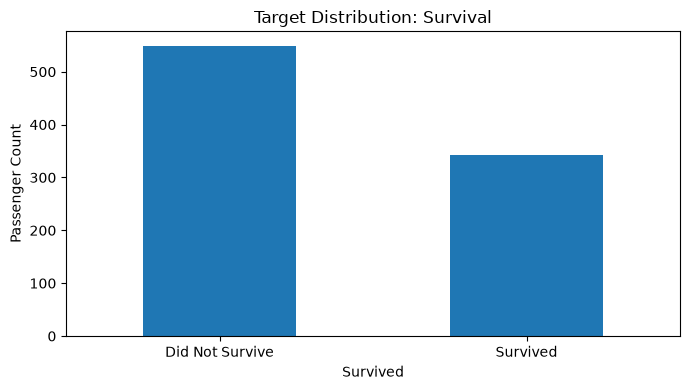

In [28]:
plt.figure(figsize=(7, 4))

df["Survived"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Target Distribution: Survival")
plt.xlabel("Survived")
plt.ylabel("Passenger Count")

plt.xticks(
    [0, 1],
    ["Did Not Survive", "Survived"],
    rotation=0
)

plt.tight_layout()
plt.show()

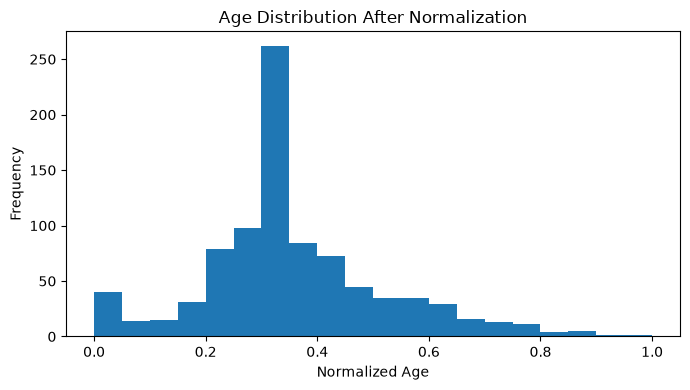

In [29]:
plt.figure(figsize=(7, 4))

plt.hist(df["Age"], bins=20)

plt.title("Age Distribution After Normalization")
plt.xlabel("Normalized Age")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

Survival rate by passenger class:


Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

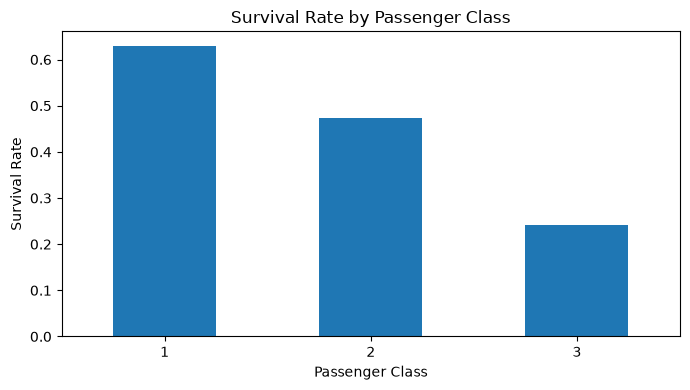

In [30]:
class_survival = (
    df.groupby("Pclass")["Survived"]
    .mean()
)

print("Survival rate by passenger class:")
display(class_survival)

plt.figure(figsize=(7, 4))

class_survival.plot(kind="bar")

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

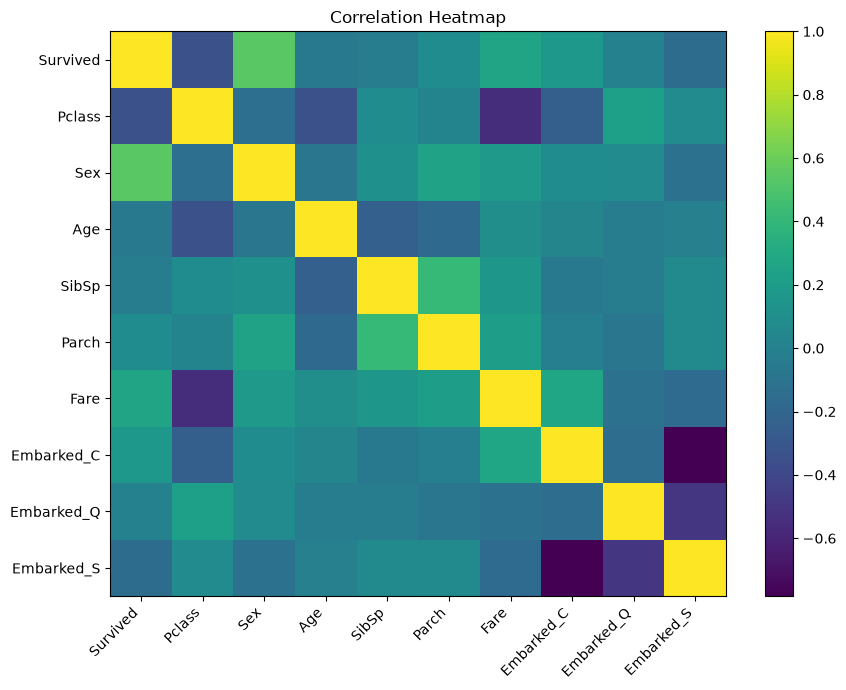

In [31]:
correlation = df.corr(numeric_only=True)

plt.figure(figsize=(9, 7))

plt.imshow(
    correlation,
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

## 9. Export Cleaned Dataset

The final processed dataset is exported as `titanic_cleaned.csv`.

This file contains only processed numerical features and contains no missing values. It can be used as an input for subsequent machine-learning modeling tasks.

In [32]:
OUTPUT_FILE = DATA_DIR / "titanic_cleaned.csv"

df.to_csv(
    OUTPUT_FILE,
    index=False
)

print("Cleaned dataset saved to:")
print(OUTPUT_FILE)

Cleaned dataset saved to:
d:\yuva-intern\project\YuvaIntern_Week1_Titanic_Project\data\titanic_cleaned.csv


# Conclusion

This project demonstrated a complete introductory data-preprocessing workflow using the Titanic passenger dataset.

The raw dataset was inspected and its missing values were identified. Irrelevant identifiers and unsuitable high-cardinality or heavily incomplete columns were removed. Missing `Age` values were handled using median imputation, while missing `Embarked` values were replaced using the mode.

Categorical data was converted into numerical form using binary encoding and one-hot encoding. Selected numerical features were normalized using Min-Max scaling. Exploratory data analysis was then performed to understand the target distribution, age distribution, passenger-class survival pattern, and feature correlations.

The final dataset contains **891 rows and 10 columns with zero missing values**. The processed dataset is therefore suitable for use in subsequent machine-learning modeling tasks.

This exercise demonstrates the importance of data quality, appropriate preprocessing decisions, and exploratory analysis before training machine-learning models.